# Salary Prediction notebook

## Imports

In [ ]:
#importing dataset
import kagglehub
path = kagglehub.dataset_download("nalisha/job-salary-prediction-dataset")

print("Path to dataset files:", path)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


Using Colab cache for faster access to the 'job-salary-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/job-salary-prediction-dataset


In [ ]:
file_path = os.path.join(path, "job_salary_prediction_dataset.csv")

df = pd.read_csv(file_path)

#Previewing the dataframe
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


**No Null values, no missing or dupes, the dataframe is a mix between numeric and catagorical features, if nulls did exist in the dataframe those entries would be further evaluated and either purged or imputed with mean/median**

## Exploratory Data Analysis (EDA)

In [ ]:
#Summary Dataframe looking at data Quality
summary_df = pd.DataFrame({
    "Total nulls" : df.isnull().sum(),
    "Unique values" : df.nunique(),
    "Total Missing Values" : df.apply(lambda x: x.isna().sum()),
    "total dupes" : df.duplicated().sum(),
    "Data type": df.dtypes
})

summary_df

,Total nulls,Unique values,Total Missing Values,total dupes,Data type
job_title,0,12,0,0,object
experience_years,0,21,0,0,int64
education_level,0,5,0,0,object
skills_count,0,19,0,0,int64
industry,0,10,0,0,object
company_size,0,5,0,0,object
location,0,10,0,0,object
remote_work,0,3,0,0,object
certifications,0,6,0,0,int64
salary,0,118956,0,0,int64


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
experience_years,250000.0,10.005408,6.060602,0.0,5.0,10.0,15.0,20.0
skills_count,250000.0,9.997812,5.479288,1.0,5.0,10.0,15.0,19.0
certifications,250000.0,2.491928,1.706475,0.0,1.0,2.0,4.0,5.0
salary,250000.0,145718.080524,37407.952729,31867.0,119358.0,143453.0,169492.0,333046.0


In [ ]:
#Feature Engineering to compute 2 new features

# Feature 1: combined effect of experience and skills
df["experience_skill_interaction"] = df["experience_years"] * df["skills_count"]

# Feature 2: certifications relative to experience
df["certifications_per_year"] = df["certifications"] / (df["experience_years"] + 1)

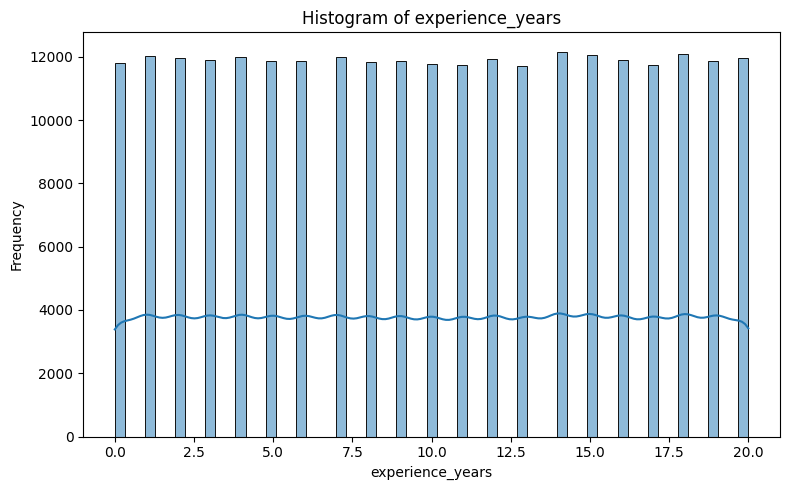

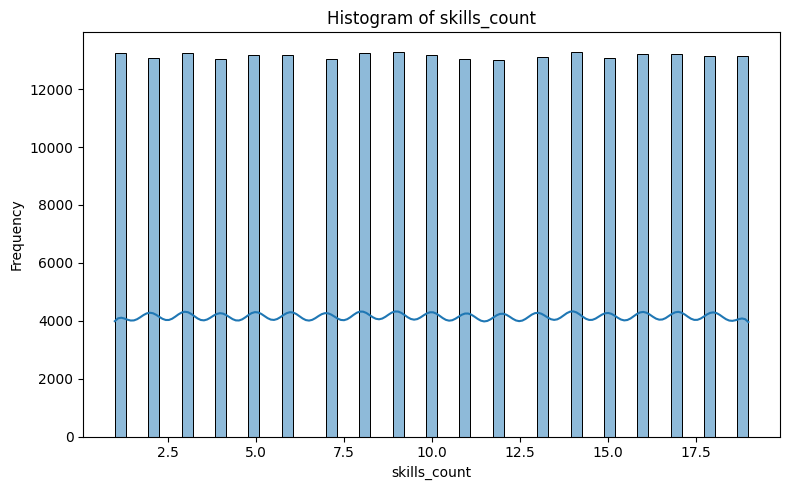

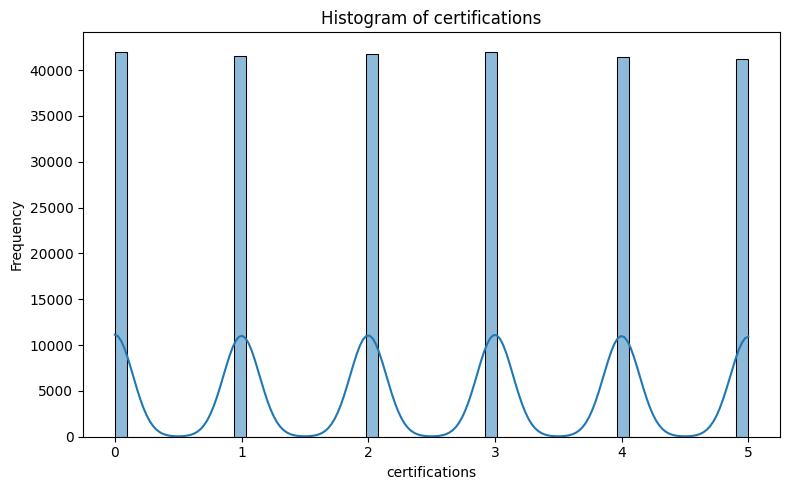

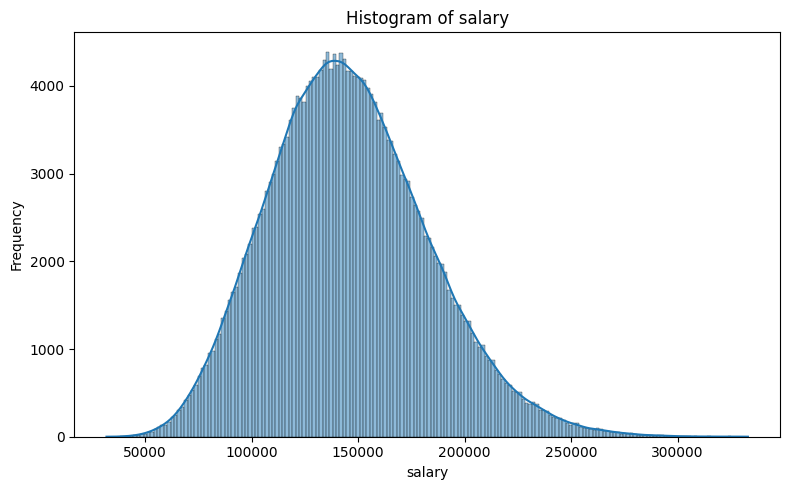

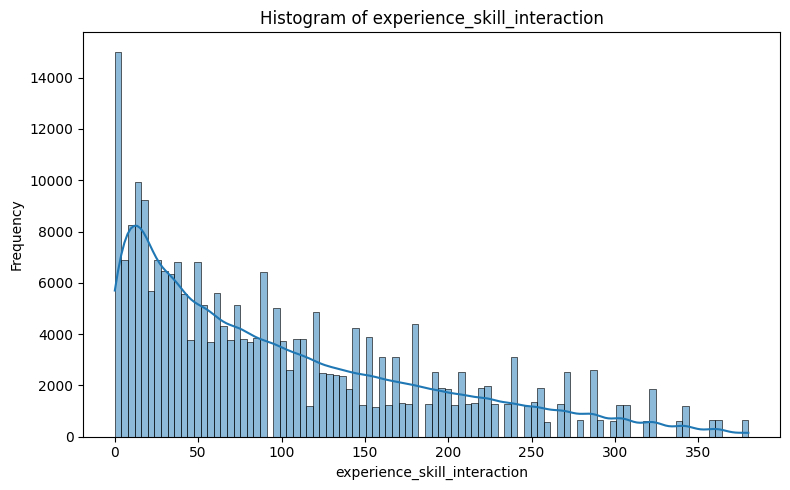

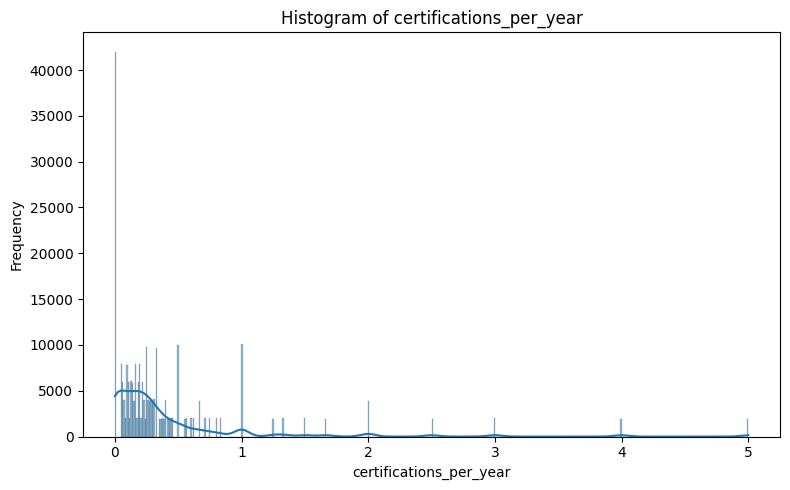

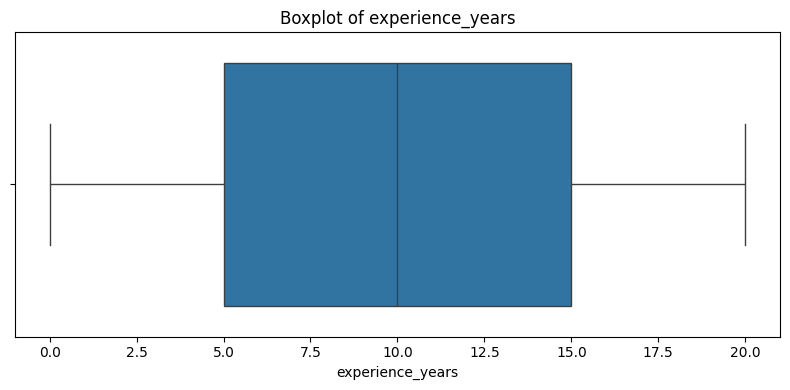

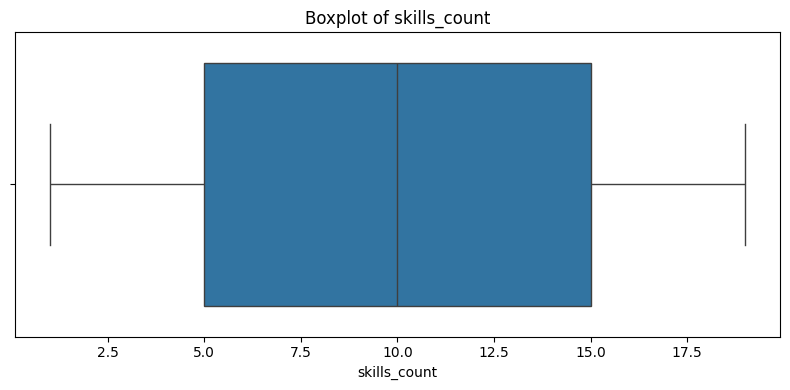

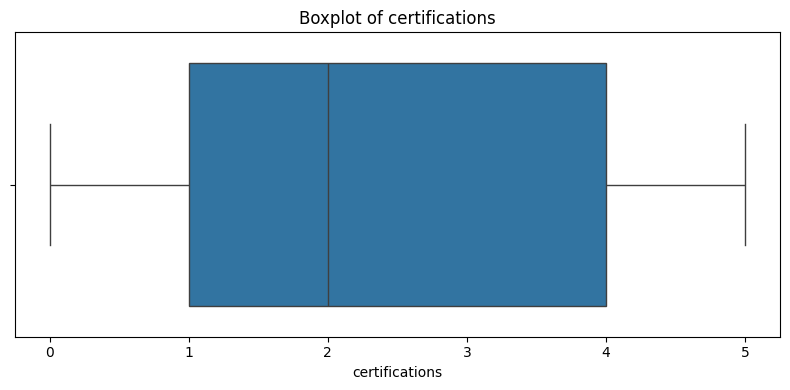

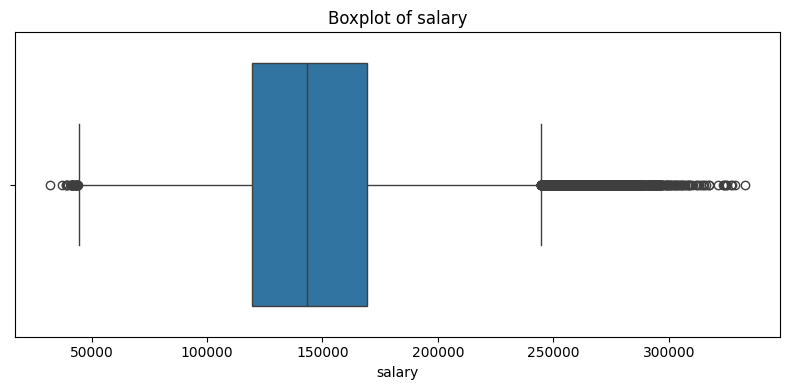

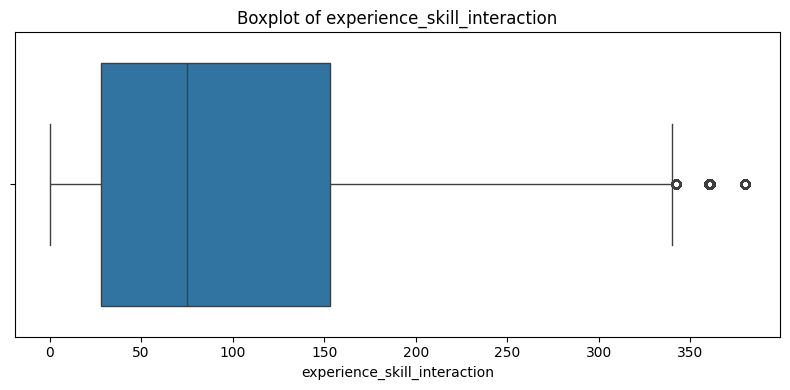

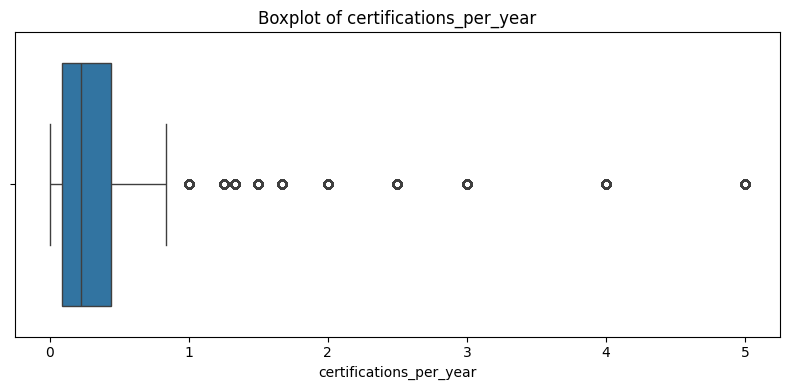

In [ ]:
#To plot Histograms and Boxplots for numerical features
#isolate the numerical features (Only int64's)
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Histograms for each numerical feature
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Boxplots for each numerical feature
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

**Pearson correlation was used to see which features correlate more to a higher salary, from the analysis it seems as though years of experience and the computed experience skill interaction have the most correlation with a higher salary**

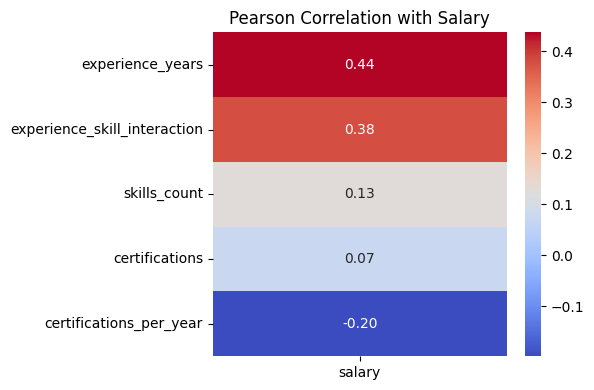

In [ ]:
# Select numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Correlation of each numeric feature with salary
salary_corr = numeric_df.corr(method="pearson")["salary"].drop("salary").sort_values(ascending=False)

plt.figure(figsize=(6, 4))
sns.heatmap(salary_corr.to_frame(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation with Salary")
plt.tight_layout()
plt.show()

## Machine Learning

In [ ]:
#Features & Target
X = df.drop(columns=["salary"])
y = df["salary"]

#Splitting column types
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']
Numeric features: ['experience_years', 'skills_count', 'certifications', 'experience_skill_interaction', 'certifications_per_year']


In [ ]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Pre Processing

In [ ]:
#First inspect the ordinal features
print("Company Size", df['company_size'].unique())
print("")
print("Education level", df['education_level'].unique())

Company Size ['Medium' 'Small' 'Large' 'Enterprise' 'Startup']

Education level ['Bachelor' 'PhD' 'High School' 'Diploma' 'Master']


In [ ]:
#Define the ordinal mappings
education_order = [['High School','Diploma','Bachelor','Master','PhD']]
company_size_order = [['Startup','Small','Medium','Large','Enterprise']]

#split categoricals by type
ordinal_features_education = ['education_level']
ordinal_features_company_size = ['company_size']
nominal_features = ['job_title', 'industry', 'location', 'remote_work']

preprocessor = ColumnTransformer(transformers=[
    ("num",     StandardScaler(),                                          numeric_features),
    ("ord_edu", OrdinalEncoder(categories=education_order),               ordinal_features_education),
    ("ord_co",  OrdinalEncoder(categories=company_size_order),            ordinal_features_company_size),
    ("cat",     OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal_features),
])

### Linear Regression Model

In [ ]:
#Linear Regression pipeline
linear_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)
y_pred_linear = linear_pipeline.predict(X_test)

#Linear Regression Results
print("LINEAR REGRESSION RESULTS")
print("MAE:", mean_absolute_error(y_test, y_pred_linear))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_linear)))
print("R²:", r2_score(y_test, y_pred_linear))

LINEAR REGRESSION RESULTS
MAE: 6059.235840390669
RMSE: 7875.325426690827
R²: 0.9553763771741941


### Random Forest Regressor Model

In [ ]:
#Random Forest Regressor Pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=5,
        n_jobs =-1,
        random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

#Random Forest Regressor Results
print("\nRANDOM FOREST RESULTS")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R²:", r2_score(y_test, y_pred_rf))


RANDOM FOREST RESULTS
MAE: 5424.174320943679
RMSE: 6829.610921854114
R²: 0.9664401713895765


**Gradient Boosting Regressor model**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,random_state=42))
])

gb_pipeline.fit(X_train, y_train)
y_pred_gb = gb_pipeline.predict(X_test)

print("\nGRADIENT BOOSTING RESULTS")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R²:", r2_score(y_test, y_pred_gb))


GRADIENT BOOSTING RESULTS
MAE: 4899.134202285031
RMSE: 6180.877248348193
R²: 0.9725129554952896
